# Wine Quality Prediction using K-Nearest Neighbors (KNN)

## **IT25101499**
## **Madubasha W M N**

# 1.Importing the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score)
from sklearn.decomposition import PCA

%matplotlib inline
sns.set(style="whitegrid")

## 2.Load the Dataset
Load the team's shared `processed_wine_quality.csv` (red + white wine combined, already standardized, with PCA components and an encoded `wine_type`). A readable `wine_type` label is derived from `wine_type_encoded` for the EDA plots.

In [2]:
import os, json

# Team repo file - try the notebook folder, the parent folder, then data/
CANDIDATE_PATHS = ["processed_wine_quality.csv",
                   "../processed_wine_quality.csv",
                   "data/processed_wine_quality.csv"]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("processed_wine_quality.csv not found. Looked in: " + ", ".join(CANDIDATE_PATHS))
df = pd.read_csv(DATA_PATH)

# Preprocessing varieties used for modelling
FULL_FEATURES = ['fixed acidity_scaled', 'volatile acidity_scaled', 'citric acid_scaled',
                 'residual sugar_scaled', 'chlorides_scaled', 'free sulfur dioxide_scaled',
                 'total sulfur dioxide_scaled', 'density_scaled', 'pH_scaled',
                 'sulphates_scaled', 'alcohol_scaled', 'wine_type_encoded']   # Variety 1
PCA_FEATURES = ['PC1', 'PC2']                                                  # Variety 2

missing_cols = [c for c in FULL_FEATURES + PCA_FEATURES + ["quality"] if c not in df.columns]
if missing_cols:
    raise KeyError("Columns missing from " + DATA_PATH + ": " + str(missing_cols))

# Readable label for EDA plots (lower code = red, higher code = white)
df["wine_type"] = np.where(df["wine_type_encoded"] > df["wine_type_encoded"].min(), "white", "red")

print("Loaded:", DATA_PATH)
print("Combined shape:", df.shape)
print("Features:", list(df.columns))
df.head()

Loaded: processed_wine_quality.csv
Combined shape: (4773, 31)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'fixed acidity_scaled', 'volatile acidity_scaled', 'citric acid_scaled', 'residual sugar_scaled', 'chlorides_scaled', 'free sulfur dioxide_scaled', 'total sulfur dioxide_scaled', 'density_scaled', 'pH_scaled', 'sulphates_scaled', 'alcohol_scaled', 'TotalAcidity', 'wine_type', 'wine_type_encoded', 'quality', 'Quality_Low', 'Quality_Medium', 'Quality_High', 'PC1', 'PC2']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,alcohol_scaled,TotalAcidity,wine_type,wine_type_encoded,quality,Quality_Low,Quality_Medium,Quality_High,PC1,PC2
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,...,0.202899,8.10,red,0,5,True,False,False,3.896895,-0.163931
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,...,0.260870,8.68,red,0,5,True,False,False,4.094157,0.620242
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,...,0.260870,8.56,red,0,5,True,False,False,3.988469,0.323965
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,...,0.260870,11.48,red,0,6,False,True,False,2.293903,1.745192
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,...,0.202899,8.06,red,0,5,True,False,False,3.692279,-0.125975


## 3.Exploratory Data Analysis - EDA
### shape, dtypes, head/tail, describe, missing, duplicates

In [3]:
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.tail())
print(df.describe())
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Quality value counts:\n", df["quality"].value_counts().sort_index())
print("Wine type counts:\n", df["wine_type"].value_counts())

(4773, 31)
fixed acidity                  float64
volatile acidity               float64
citric acid                    float64
residual sugar                 float64
chlorides                      float64
free sulfur dioxide            float64
total sulfur dioxide           float64
density                        float64
pH                             float64
sulphates                      float64
alcohol                        float64
fixed acidity_scaled           float64
volatile acidity_scaled        float64
citric acid_scaled             float64
residual sugar_scaled          float64
chlorides_scaled               float64
free sulfur dioxide_scaled     float64
total sulfur dioxide_scaled    float64
density_scaled                 float64
pH_scaled                      float64
sulphates_scaled               float64
alcohol_scaled                 float64
TotalAcidity                   float64
wine_type                          str
wine_type_encoded                int64
quality       

# 4.Visual EDA: class balance, quality distribution

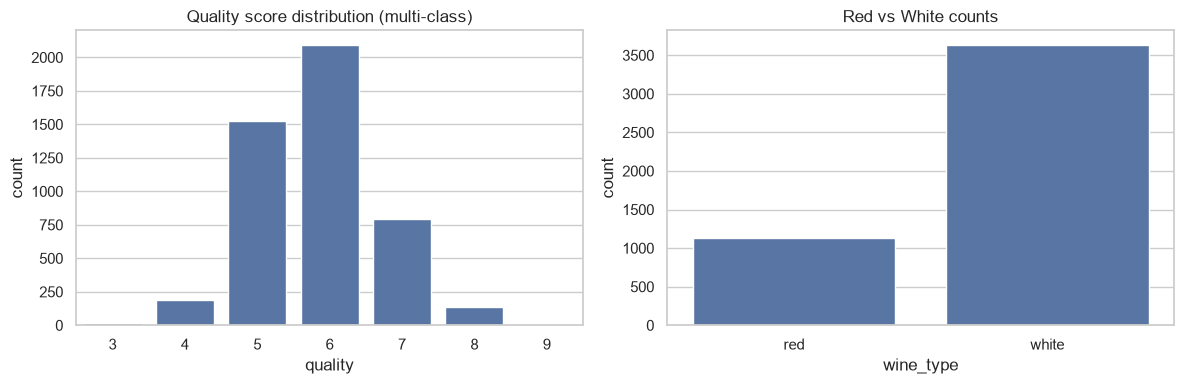

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="quality", data=df, ax=axes[0])
axes[0].set_title("Quality score distribution (multi-class)")
sns.countplot(x="wine_type", data=df, ax=axes[1])
axes[1].set_title("Red vs White counts")
plt.tight_layout(); plt.show()



# Correlation
Correlation heatmap (numeric cols only)

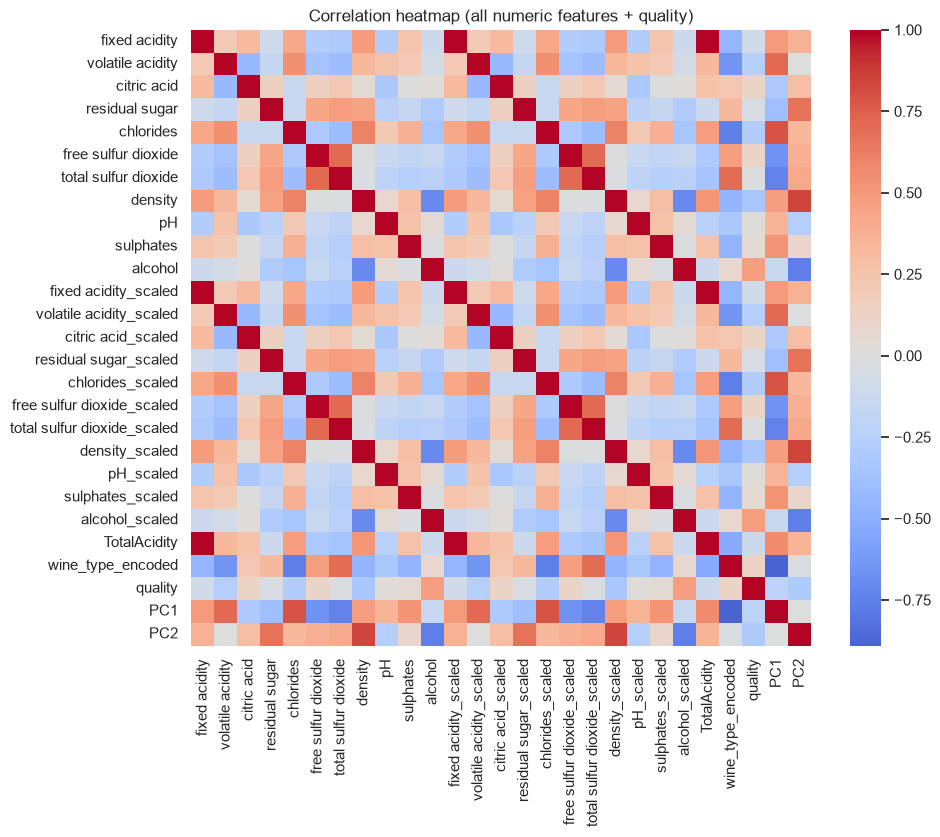

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (all numeric features + quality)")
plt.show()

# Boxplots
Boxplots for outlier check

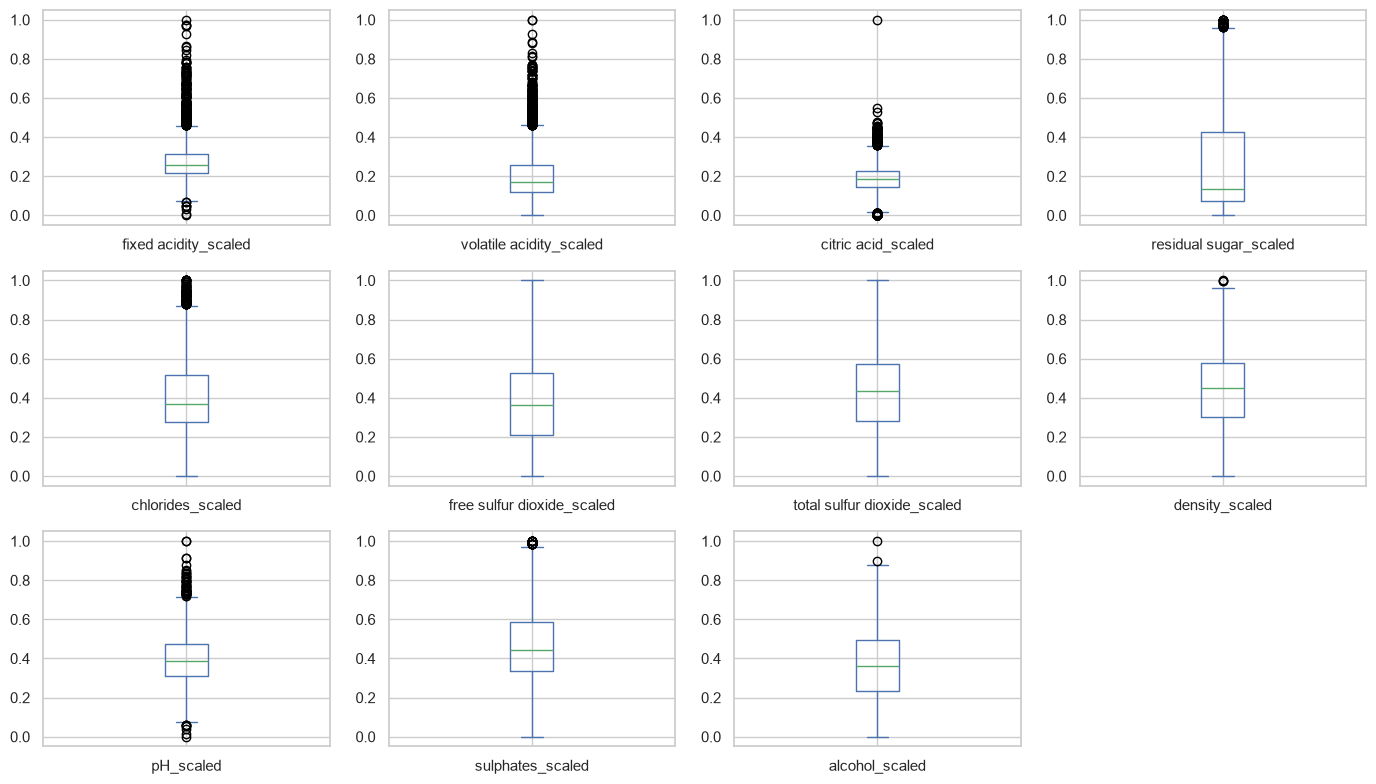

In [6]:
num_cols = [c for c in FULL_FEATURES if c != "wine_type_encoded"]   # the 11 scaled numeric features
df[num_cols].plot(kind="box", subplots=True, layout=(3, 4), figsize=(14, 8), sharey=False)
plt.tight_layout(); plt.show()

# 5.Preprocessing
Create binary target `good_quality` and build two preprocessing varieties from `processed_wine_quality.csv`: **Variety 1** = 12 standardized features, **Variety 2** = PCA features (PC1, PC2). Stratified 80/20 split.

## Binary target
quality >= 7 is 'good' (handles class order + imbalance noted in winequality.names)

good_quality
0    3833
1     940
Name: count, dtype: int64
good_quality
0    0.803059
1    0.196941
Name: proportion, dtype: float64


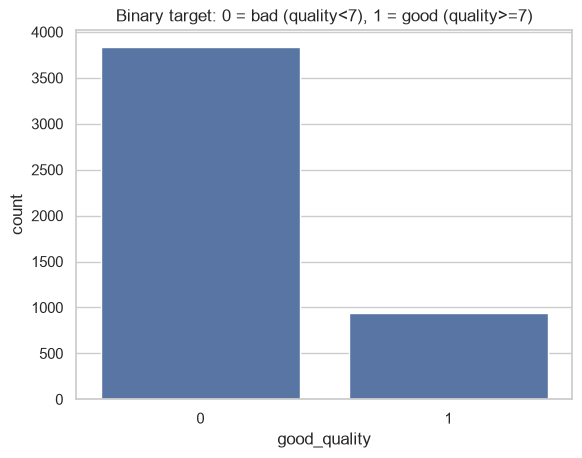

In [7]:
df["good_quality"] = (df["quality"] >= 7).astype(int)
print(df["good_quality"].value_counts())
print(df["good_quality"].value_counts(normalize=True))

sns.countplot(x="good_quality", data=df)
plt.title("Binary target: 0 = bad (quality<7), 1 = good (quality>=7)")
plt.show()

## Features / label 
Raw quality is excluded from the inputs (target leakage).
##### Variety 1 = Full Features (12 standardized, incl. wine_type_encoded) | Variety 2 = PCA Features (PC1, PC2)

In [8]:
X_full = df[FULL_FEATURES]     # Variety 1
X_pca = df[PCA_FEATURES]       # Variety 2
y = df["good_quality"]
print("Variety 1 (Full) X shape:", X_full.shape, "| Variety 2 (PCA) X shape:", X_pca.shape, "| y shape:", y.shape)
print(list(X_full.columns))
print(list(X_pca.columns))

Variety 1 (Full) X shape: (4773, 12) | Variety 2 (PCA) X shape: (4773, 2) | y shape: (4773,)
['fixed acidity_scaled', 'volatile acidity_scaled', 'citric acid_scaled', 'residual sugar_scaled', 'chlorides_scaled', 'free sulfur dioxide_scaled', 'total sulfur dioxide_scaled', 'density_scaled', 'pH_scaled', 'sulphates_scaled', 'alcohol_scaled', 'wine_type_encoded']
['PC1', 'PC2']


# 6.Train/test split
Features in `processed_wine_quality.csv` are already standardized, so no scaler is fitted here. Both varieties share the same stratified 80/20 split.

In [9]:
X_train_full, X_test_full, X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_full, X_pca, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train_full.shape[0]}, Test: {X_test_full.shape[0]}")

# Variety 1 arrays under the names the baseline / PCA-plot cells below use
X_train_scaled = X_train_full.values
X_test_scaled = X_test_full.values

Train: 3818, Test: 955


### verify features are standardized (mean ~0, std ~1)

In [10]:
print(pd.DataFrame(X_train_scaled, columns=FULL_FEATURES).head())
print(pd.DataFrame(X_train_scaled, columns=FULL_FEATURES).describe().round(2))

   fixed acidity_scaled  volatile acidity_scaled  citric acid_scaled  \
0              0.272727                    0.280            0.253012   
1              0.214876                    0.240            0.144578   
2              0.264463                    0.072            0.253012   
3              0.148760                    0.136            0.114458   
4              0.297521                    0.256            0.174699   

   residual sugar_scaled  chlorides_scaled  free sulfur dioxide_scaled  \
0               0.317152          0.613861                    0.361111   
1               0.427184          0.376238                    0.541667   
2               0.025890          0.653465                    0.236111   
3               0.116505          0.396040                    0.555556   
4               0.310680          0.346535                    0.402778   

   total sulfur dioxide_scaled  density_scaled  pH_scaled  sulphates_scaled  \
0                     0.482213        0.633

## 7.Train KNN

In [11]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
print("KNN(k=5) trained on", X_train_scaled.shape)

KNN(k=5) trained on (3818, 12)


# 8.Evaluate
### BASELINE model: default KNN k=5 - single solid accuracy to submit

BASELINE ACCURACY k=5: 0.8157
Precision: 0.5395
Recall   : 0.4362
F1-score : 0.4824
ROC AUC  : 0.789

              precision    recall  f1-score   support

         bad       0.87      0.91      0.89       767
        good       0.54      0.44      0.48       188

    accuracy                           0.82       955
   macro avg       0.70      0.67      0.69       955
weighted avg       0.80      0.82      0.81       955



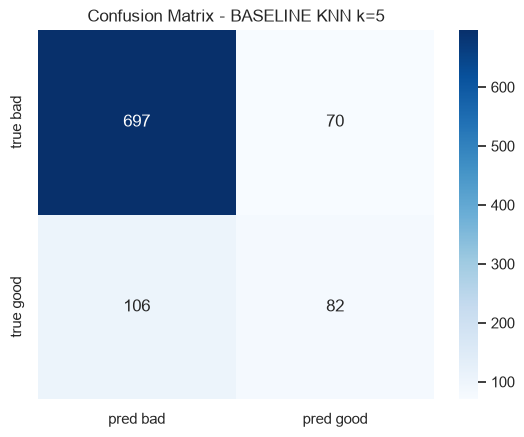

In [12]:
y_pred_knn = model_knn.predict(X_test_scaled)
y_proba_knn = model_knn.predict_proba(X_test_scaled)[:, 1]

BASELINE_ACC = accuracy_score(y_test, y_pred_knn)
print("BASELINE ACCURACY k=5: %.4f" % BASELINE_ACC)
print("Precision:", round(precision_score(y_test, y_pred_knn), 4))
print("Recall   :", round(recall_score(y_test, y_pred_knn), 4))
print("F1-score :", round(f1_score(y_test, y_pred_knn), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba_knn), 4))
print("\n" + classification_report(y_test, y_pred_knn, target_names=["bad", "good"]))

cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred bad", "pred good"],
            yticklabels=["true bad", "true good"])
plt.title("Confusion Matrix - BASELINE KNN k=5")
plt.show()

# 9.Visualize Decision Boundary via PCA
KNN has 12 features so we compress to 2D with PCA purely for visualization, then retrain a 2D KNN.

Explained variance: [0.534 0.186]


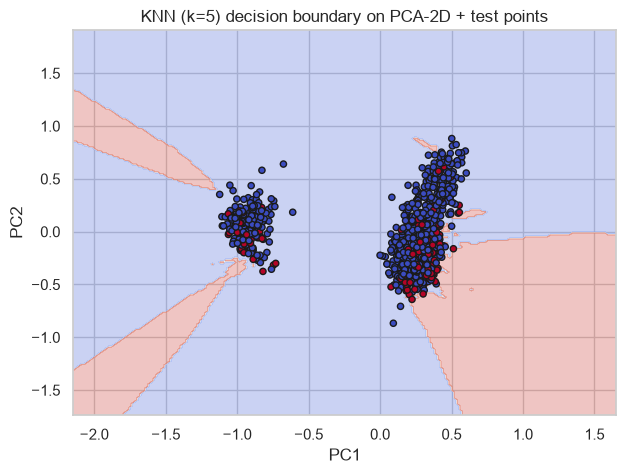

In [13]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)
print("Explained variance:", pca.explained_variance_ratio_.round(3))

viz_knn = KNeighborsClassifier(n_neighbors=5)
viz_knn.fit(X_train_2d, y_train)

xx, yy = np.meshgrid(np.linspace(X_train_2d[:, 0].min()-1, X_train_2d[:, 0].max()+1, 200),
                     np.linspace(X_train_2d[:, 1].min()-1, X_train_2d[:, 1].max()+1, 200))
Z = viz_knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap="coolwarm", edgecolor="k", s=20)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("KNN (k=5) decision boundary on PCA-2D + test points")
plt.show()

# 10.Hyperparameter Tuning (GridSearchCV on both varieties)
Replaces the manual K sweep. 5-fold Stratified CV, `scoring='f1_weighted'`, searching `n_neighbors`, `weights` and `metric` separately on **Variety 1 (Full)** and **Variety 2 (PCA)**.

Variety 1 - Full Features
  Best CV weighted F1: 0.8187
  Best params        : {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Variety 2 - PCA Features
  Best CV weighted F1: 0.7733
  Best params        : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}


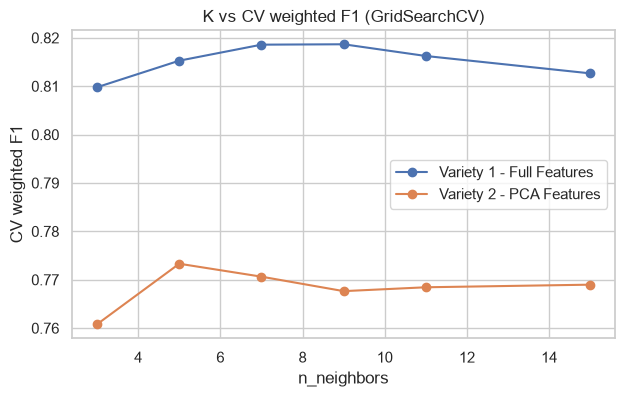

In [14]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

varieties = {
    "Variety 1 - Full Features": (X_train_full, X_test_full),
    "Variety 2 - PCA Features":  (X_train_pca, X_test_pca),
}

grids = {}
for name, (Xtr, Xte) in varieties.items():
    g = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1)
    g.fit(Xtr, y_train)
    grids[name] = g
    print(name)
    print("  Best CV weighted F1: %.4f" % g.best_score_)
    print("  Best params        :", g.best_params_)

# K vs CV weighted F1 (best setting for each k), both varieties
fig, ax = plt.subplots(figsize=(7, 4))
for name, g in grids.items():
    r = pd.DataFrame(g.cv_results_)
    r["k"] = r["param_n_neighbors"].astype(int)
    r.groupby("k")["mean_test_score"].max().plot(marker="o", ax=ax, label=name)
ax.set_xlabel("n_neighbors"); ax.set_ylabel("CV weighted F1")
ax.set_title("K vs CV weighted F1 (GridSearchCV)")
ax.legend(); ax.grid(True); plt.show()

# 11.Evaluate the winning model
The variety with the higher CV weighted F1 wins (chosen on CV only, never on the test set). The winner is then scored once on the held-out test set. Its accuracy is compared with the BASELINE.

In [15]:
# Both varieties on the test set (for the comparison table)
rows = []
for name, (Xtr, Xte) in varieties.items():
    p = grids[name].best_estimator_.predict(Xte)
    rows.append({"variety": name, "cv_weighted_f1": grids[name].best_score_,
                 "test_accuracy": accuracy_score(y_test, p),
                 "test_weighted_f1": f1_score(y_test, p, average="weighted"),
                 "best_params": str(grids[name].best_params_)})
variety_table = pd.DataFrame(rows)
print(variety_table.to_string(index=False))

# Winner = highest CV weighted F1
winner_name = max(grids, key=lambda n: grids[n].best_score_)
grid = grids[winner_name]
X_test_win = varieties[winner_name][1]
print("\nWINNING PREPROCESSING:", winner_name)
print("Best params:", grid.best_params_)
print("Best CV weighted F1: %.4f" % grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_win)
y_proba_best = best_model.predict_proba(X_test_win)[:, 1]

TUNED_ACC = accuracy_score(y_test, y_pred_best)
print("\nFINAL TEST METRICS (winning model)")
print("Accuracy      : %.4f" % TUNED_ACC)
print("Precision     : %.4f (weighted)" % precision_score(y_test, y_pred_best, average="weighted"))
print("Recall        : %.4f (weighted)" % recall_score(y_test, y_pred_best, average="weighted"))
print("Weighted F1   : %.4f" % f1_score(y_test, y_pred_best, average="weighted"))
print("Macro F1      : %.4f" % f1_score(y_test, y_pred_best, average="macro"))
print("ROC AUC       : %.4f" % roc_auc_score(y_test, y_proba_best))
print("BASELINE TEST ACCURACY (k=5, full features): %.4f" % BASELINE_ACC)
print("IMPROVEMENT: %+.4f" % (TUNED_ACC - BASELINE_ACC))
print("\n" + classification_report(y_test, y_pred_best, target_names=["bad", "good"]))

                  variety  cv_weighted_f1  test_accuracy  test_weighted_f1                                                      best_params
Variety 1 - Full Features        0.818662       0.825131          0.816225 {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
 Variety 2 - PCA Features        0.773307       0.794764          0.773612  {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

WINNING PREPROCESSING: Variety 1 - Full Features
Best params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best CV weighted F1: 0.8187

FINAL TEST METRICS (winning model)
Accuracy      : 0.8251
Precision     : 0.8117 (weighted)
Recall        : 0.8251 (weighted)
Weighted F1   : 0.8162
Macro F1      : 0.6963
ROC AUC       : 0.8193
BASELINE TEST ACCURACY (k=5, full features): 0.8157
IMPROVEMENT: +0.0094

              precision    recall  f1-score   support

         bad       0.87      0.92      0.89       767
        good       0.57      0.44      0.50  

# 12.Accuracy

In [16]:
summary = pd.DataFrame({"model": ["BASELINE k=5", str(grid.best_params_)], "accuracy": [BASELINE_ACC, TUNED_ACC]})
print(summary)

                                               model  accuracy
0                                       BASELINE k=5  0.815707
1  {'metric': 'manhattan', 'n_neighbors': 9, 'wei...  0.825131


### Barchart

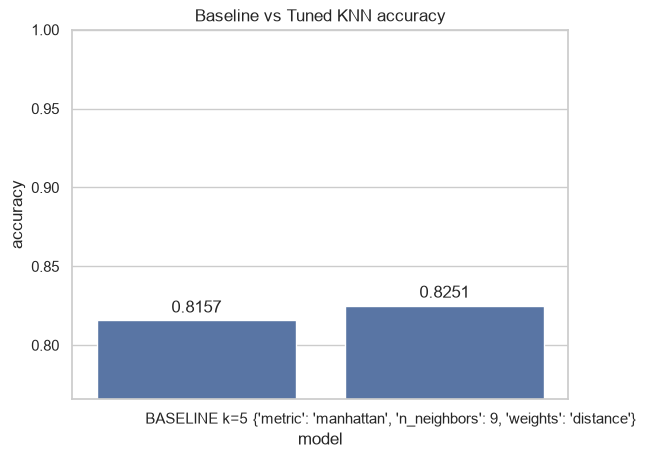

In [17]:
sns.barplot(x="model", y="accuracy", data=summary)
plt.ylim(max(0, min(BASELINE_ACC, TUNED_ACC)-0.05), 1.0)
plt.title("Baseline vs Tuned KNN accuracy")
for i, v in enumerate(summary["accuracy"]):
    plt.text(i, v+0.005, "%.4f" % v, ha="center")
plt.show()


### Comparison Table

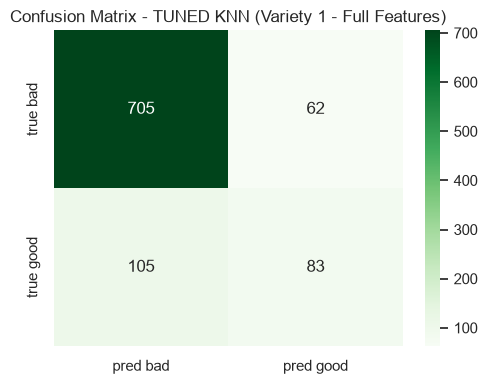

Saved confusion matrix to ../results


In [18]:
# Output folder: reuse an existing results folder, otherwise create one next to the data
RESULTS_DIR = next((d for d in ["../results", "results"] if os.path.isdir(d)),
                   "../results" if DATA_PATH.startswith("..") else "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Greens",
            xticklabels=["pred bad", "pred good"], yticklabels=["true bad", "true good"])
plt.title("Confusion Matrix - TUNED KNN (" + winner_name + ")")
plt.tight_layout()
for fname in ["IT25101499_cm.png", "knn_cm.png"]:
    plt.savefig(os.path.join(RESULTS_DIR, fname), dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to", RESULTS_DIR)

### ROC Curve

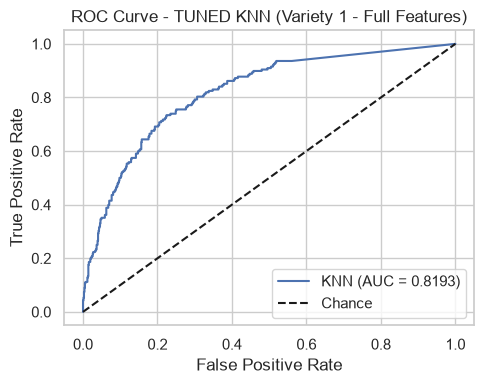

Saved ROC curve to ../results


In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_val = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label="KNN (AUC = %.4f)" % auc_val)
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TUNED KNN (" + winner_name + ")")
plt.legend(loc="lower right")
plt.tight_layout()
for fname in ["IT25101499_roc.png", "knn_roc.png"]:
    plt.savefig(os.path.join(RESULTS_DIR, fname), dpi=150, bbox_inches="tight")
plt.show()
print("Saved ROC curve to", RESULTS_DIR)

# 13.Export metrics for the group comparison
Writes `IT25101499_metrics.json` (same keys as the other team notebooks) so `Group.ipynb` can load it.

In [20]:
metrics_out = {
    "student_id": "IT25101499",
    "student_name": "Madubasha W M N",
    "model": "KNN",
    "best_params": {k: (int(v) if isinstance(v, (int, np.integer)) else v) for k, v in grid.best_params_.items()},
    "cv_weighted_f1": float(grid.best_score_),
    "accuracy": float(accuracy_score(y_test, y_pred_best)),
    "precision": float(precision_score(y_test, y_pred_best, average="weighted")),
    "recall": float(recall_score(y_test, y_pred_best, average="weighted")),
    "weighted_f1": float(f1_score(y_test, y_pred_best, average="weighted")),
    "macro_f1": float(f1_score(y_test, y_pred_best, average="macro")),
    "roc_auc": float(roc_auc_score(y_test, y_proba_best)),
    "confusion_matrix": confusion_matrix(y_test, y_pred_best).tolist(),
    "roc_curve": {"fpr": [float(v) for v in fpr], "tpr": [float(v) for v in tpr]},
}

json_path = os.path.join(RESULTS_DIR, "IT25101499_metrics.json")
with open(json_path, "w") as f:
    json.dump(metrics_out, f, indent=2)
print("Saved", json_path)
print({k: v for k, v in metrics_out.items() if k not in ("confusion_matrix", "roc_curve")})

Saved ../results\IT25101499_metrics.json
{'student_id': 'IT25101499', 'student_name': 'Madubasha W M N', 'model': 'KNN', 'best_params': {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}, 'cv_weighted_f1': 0.8186624124632967, 'accuracy': 0.8251308900523561, 'precision': 0.8117150441649449, 'recall': 0.8251308900523561, 'weighted_f1': 0.8162246168520922, 'macro_f1': 0.6963006125973785, 'roc_auc': 0.8192876362728508}


## Conclusion
- Baseline: default KNN (k=5, Euclidean, uniform weights) on the 12 standardized features - single reference accuracy.
- Tuning: 5-fold Stratified `GridSearchCV` (`f1_weighted`) over `n_neighbors`, `weights` and `metric`, run on Variety 1 (Full Features) and Variety 2 (PCA PC1/PC2). The variety with the higher CV weighted F1 is the winner (see the comparison table in section 11).
- Final test metrics (Accuracy, Precision, Recall, Weighted F1, Macro F1, ROC-AUC), the confusion matrix, the ROC curve and `IT25101499_metrics.json` are all produced from the winning model.
- Why it can boost: distance weighting and Manhattan distance can help on imbalanced, skewed wine features; larger K smooths noisy boundaries. A 2-component PCA keeps less information than the full 12 features, which the comparison table makes visible.